In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2000-01-01", end="2025-10-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# 로그 변화율 계산
returns["log_change"] = np.log(returns["Close"] / returns["Close"].shift(1))

# 비율 변화량 계산 (pct_change 사용)
returns["change"] = returns["Close"].pct_change()

# change를 logchange로부터 복구
returns["test"] = np.exp(returns["log_change"]) - 1

# 불필요한 NaN 값 제거
returns = returns.dropna()

# 필요한 열만 선택
returns = returns[["Close", "change", "log_change", "test"]]

# 데이터 분할 기준일: 가장 최신 날짜 기준으로 일주일 전
split_date = returns.index[-30]

# 학습 데이터: 일주일 전까지
train_data = returns[returns.index < split_date]

# 검증 데이터: 일주일 동안
test_data = returns[returns.index >= split_date]

print(f"학습 데이터 기간: {train_data.index.min()} ~ {train_data.index.max()}")
print(f"검증 데이터 기간: {test_data.index.min()} ~ {test_data.index.max()}")

print(returns)
print(train_data)
print(test_data)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

학습 데이터 기간: 2000-01-04 00:00:00 ~ 2025-03-31 00:00:00
검증 데이터 기간: 2025-04-01 00:00:00 ~ 2025-05-13 00:00:00
Price             Close    change  log_change      test
Date                                                   
2000-01-04  1399.420044 -0.038345   -0.039099 -0.038345
2000-01-05  1402.109985  0.001922    0.001920  0.001922
2000-01-06  1403.449951  0.000956    0.000955  0.000956
2000-01-07  1441.469971  0.027090    0.026730  0.027090
2000-01-10  1457.599976  0.011190    0.011128  0.011190
...                 ...       ...         ...       ...
2025-05-07  5631.279785  0.004346    0.004337  0.004346
2025-05-08  5663.939941  0.005800    0.005783  0.005800
2025-05-09  5659.910156 -0.000711   -0.000712 -0.000711
2025-05-12  5844.189941  0.032559    0.032040  0.032559
2025-05-13  5886.549805  0.007248    0.007222  0.007248

[6378 rows x 4 columns]
Price             Close    change  log_change      test
Date                                                   
2000-01-04  1399.420044 -0.03

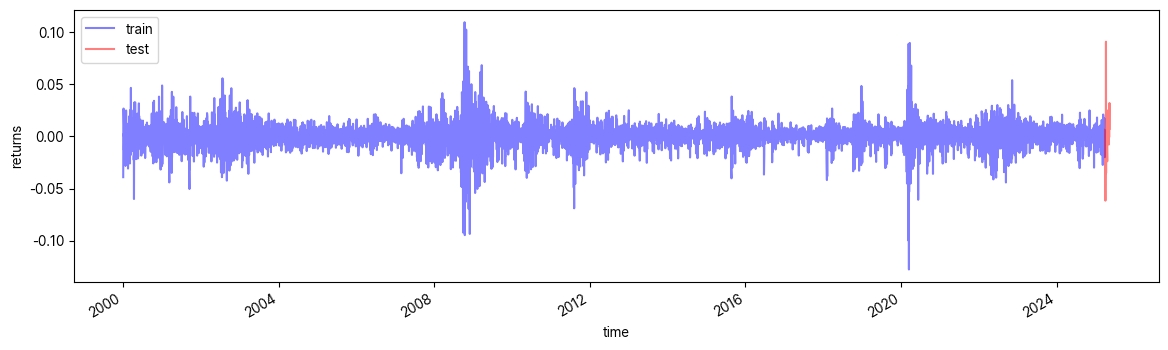

In [2]:
fig, ax = plt.subplots(figsize=(14, 4))
train_data.plot(y="log_change", label="train", ax=ax, color="blue", alpha=0.5)
test_data.plot(y="log_change", label="test", ax=ax, color="red", alpha=0.5)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [12]:
import pytensor.tensor as at  # 또는 aesara.tensor as at (PyMC 버전에 따라 다름)
# ...existing code...

def make_sv_with_vol_jump_model(data):
    T = len(data)
    with pm.Model(coords={"time": data.index.values}) as model:
        step_size = pm.Exponential("step_size", 10)
        # 변동성 Jump 파트
        p_vj = pm.Beta("p_vj", 1, 10)
        z = pm.Bernoulli("z", p=p_vj, dims="time")
        mu_k = pm.Normal("mu_k", mu=0, sigma=0.1)
        sigma_k = pm.Exponential("sigma_k", 10)
        k = pm.Normal("k", mu=mu_k, sigma=sigma_k, dims="time")
        eta = pm.Normal("eta", mu=0, sigma=step_size, dims="time")
        h0 = pm.Normal("h0", mu=0, sigma=1)

        # log_volatility 길이 = T
        increments = eta + k * z
        log_volatility = pm.Deterministic(
            "log_volatility",
            h0 + at.cumsum(increments)
        )

        volatility = pm.Deterministic("volatility", pm.math.exp(log_volatility), dims="time")
        lam = pm.Deterministic("lambda", pm.math.exp(-2 * log_volatility) + 1e-6)
        nu = pm.Exponential("nu", 0.1)
        pm.StudentT(
            "returns", nu=nu, lam=lam, observed=data["log_change"], dims="time"
        )
    return model

stochastic_vol_model = make_sv_with_vol_jump_model(train_data)

In [ ]:
# def make_stochastic_volatility_model(data):
#     with pm.Model(coords={"time": data.index.values}) as model:
#         step_size = pm.Exponential("step_size", 10)
#         log_volatility = pm.GaussianRandomWalk("log_volatility", sigma=step_size, dims="time")
#         volatility = pm.Deterministic("volatility", pm.math.exp(log_volatility), dims="time")
#         lam = pm.Deterministic("lambda", pm.math.exp(-2 * log_volatility))
#         nu = pm.Exponential("nu", 0.1)
#         pm.StudentT(
#             "returns", nu=nu, lam=lam, observed=data["log_change"], dims="time"
#         )
#     return model


# stochastic_vol_model = make_stochastic_volatility_model(train_data)

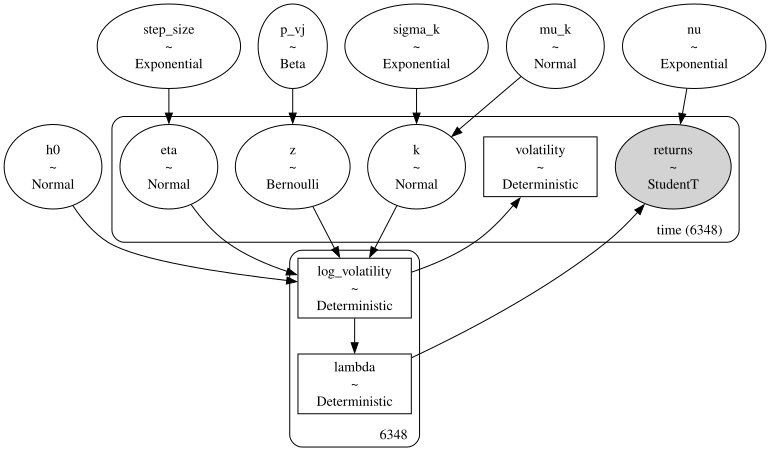

In [13]:
pm.model_to_graphviz(stochastic_vol_model)

In [14]:
rng = np.random.default_rng(1234)
az.style.use("arviz-darkgrid")

In [15]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [eta, h0, k, mu_k, nu, p_vj, returns, sigma_k, step_size, z]


In [16]:
idata

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [17]:
prior_predictive

<xarray.Dataset>
Dimensions:       (time: 6348, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 2000-01-04 2000-01-05 ... 2025-03-31
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 -0.1388 -0.6049 ... 54.84
Attributes:
    created_at:                 2025-05-14T05:43:13.421494
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

In [18]:
prior_predictive["returns"].shape

(6348, 500)

/tmp/ipykernel_34130/2910044826.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


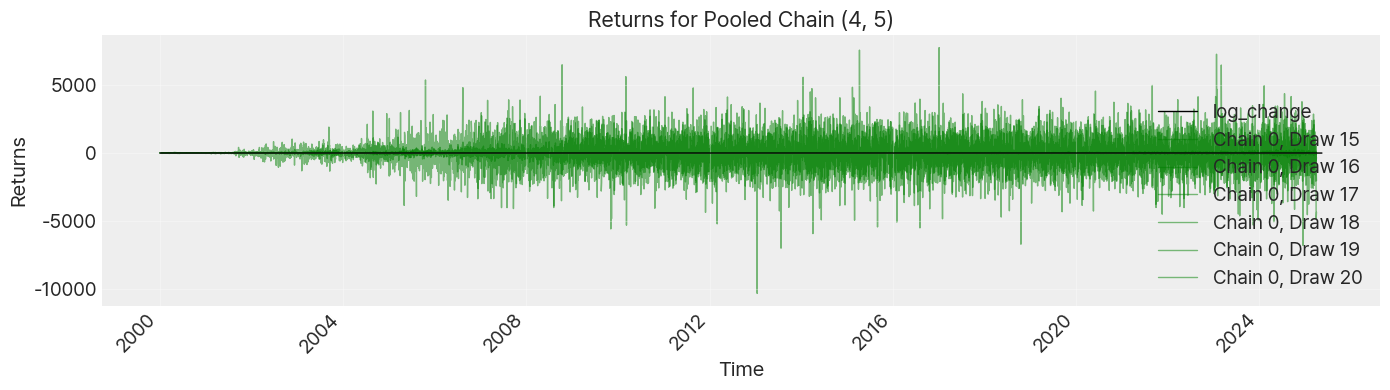

In [19]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(15, 21, None))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["log_change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# with stochastic_vol_model:
#     pm.sample(3000, random_seed=rng, target_accept=0.95, idata_kwargs={"log_likelihood": True})


In [ ]:
# import os

# # JAX의 `pmap` 병렬화를 비활성화
# os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1 --xla_gpu_autotune_level=4 --xla_gpu_reduce_scatter=1 --xla_gpu_enable_async_all_reduce=1"

# os.environ["XLA_FLAGS"]

In [ ]:
with stochastic_vol_model:
    idata.extend(pm.sample(2000, random_seed=rng, target_accept=0.9, idata_kwargs={"log_likelihood": True}, 
                        #    nuts_sampler="numpyro",
                           chains=8,        # 한 번에 하나의 체인만 실행
                           cores=8,
                           ))

posterior = idata.posterior.stack(pooled_chain=("chain", "draw"))
# posterior["volatility"] = np.exp(posterior["volatility"])

Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>NUTS: [step_size, p_vj, mu_k, sigma_k, k, eta, h0, nu]
>BinaryGibbsMetropolis: [z]


In [ ]:
# from datetime import datetime
# import arviz as az

# # 현재 날짜와 시간
# now = datetime.now()
# formatted_time = now.strftime("%Y%m%d%H%M")  # 202505081200 형식

# # 파일 저장
# az.to_netcdf(idata, f"trace-{formatted_time}.nc")

In [ ]:
posterior["volatility"]

In [ ]:
posterior

In [ ]:
idata

In [ ]:
summary = az.summary(idata)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

In [ ]:
az.plot_trace(idata, var_names=["step_size", "nu"]);

In [ ]:
az.loo(idata)

In [ ]:
with stochastic_vol_model:
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=rng)


In [ ]:
posterior_predictive

In [ ]:
posterior_predictive.posterior_predictive["returns"].shape

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
az.plot_ppc(posterior_predictive, num_pp_samples=100, ax=ax, kind="kde", alpha=0.5);
ax.set_xlim(-0.05, 0.05)

In [ ]:
az.plot_bpv(posterior_predictive, kind="t_stat", t_stat="mean")

In [ ]:
posterior

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 50))
x_vals = y_vals.time.astype(np.datetime64)

plt.plot(x_vals, y_vals, "g", alpha=0.002)
ax.set_xlim(x_vals.min(), x_vals.max())
# ax.set_ylim(bottom=0)
ax.set(title="Estimated volatility over time", xlabel="Date", ylabel="Volatility");

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["log_change"].plot(ax=axes[0], color="black")

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.002)

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)
axes[0].set_title("True returns (black) and posterior predictive returns (green)")
axes[1].set_title("Posterior volatility");
# plt.xlim(x_vals[-100], x_vals.max())

In [ ]:
idata

In [ ]:
def create_forecast_model(data, idata, forecast_steps):
    """
    data: 원본 데이터프레임
    idata: 학습된 사후분포 (InferenceData 객체)
    forecast_steps: 예측 기간
    """
    import pymc as pm
    import numpy as np

    # 기존 모델의 마지막 시점 인덱스
    last_time = data.index[-1]
    forecast_dates = pd.date_range(start=last_time, periods=forecast_steps + 1, freq="D")[0:]

    with pm.Model(coords={"forecast_time": forecast_dates}) as forecast_model:
        # 사후분포로부터 mu와 step_size의 값을 추출
        step_size = pm.Exponential("step_size", 10)
        
        # 예측을 위한 Gaussian Random Walk
        # init_volatility_value = idata.posterior["log_volatility"].sel(time=last_time).mean().item()
        # init_volatility = pm.DiracDelta.dist(init_volatility_value)

        # 사후분포에서 마지막 시점의 log_volatility 샘플 추출
        last_log_volatility_samples = idata.posterior["log_volatility"].sel(time=last_time).values.flatten()
        
        # 사후분포에서의 샘플 수
        n_samples = len(last_log_volatility_samples)
        
        # 각 샘플이 선택될 확률 (동일한 확률)
        weights = np.ones(n_samples) / n_samples
        
        # Mixture 분포로 초기값 설정 (이름이 없는 분포 생성)
        init_volatility_dist = pm.Mixture.dist(
            w=weights,
            comp_dists=pm.Normal.dist(mu=last_log_volatility_samples, sigma=1e-3)  # sigma를 작게 하여 거의 확정적인 값처럼 설정
        )

        # Gaussian Random Walk 시작점으로 설정
        forecast_log_volatility = pm.GaussianRandomWalk(
            "forecast_log_volatility", 
            sigma=step_size, 
            init_dist=init_volatility_dist, 
            dims="forecast_time"
        )

        forecast_volatility = pm.Deterministic("forecast_volatility", pm.math.exp(forecast_log_volatility), dims="forecast_time")

        # Student-T 분포의 파라미터 설정
        # sigma = pm.Deterministic("sigma", pm.math.exp(-forecast_log_volatility))
        lam = pm.Deterministic("lambda", pm.math.exp(-2 * forecast_log_volatility))
        nu = pm.Exponential("nu", 0.1)

        # 예측된 변동성에 따른 Student-T 분포 생성
        forecast_returns = pm.StudentT(
            "forecast_returns", 
            nu=nu, 
            lam=lam,
            dims="forecast_time"
        )

    return forecast_model



In [ ]:
forecast_model = create_forecast_model(train_data, idata=idata, forecast_steps=30)

with forecast_model:
    forecast_posterior = pm.sample_posterior_predictive(
        idata,
        var_names=["forecast_returns", "forecast_log_volatility", "forecast_volatility"],
        predictions=True,
        random_seed=rng
    )

In [ ]:
idata

In [ ]:
forecast_posterior

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["log_change"].plot(ax=axes[0], color="black")

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
x_vals1 = y_vals.time.astype(np.datetime64)
ax.plot(x_vals1, y_vals, "g", alpha=0.002,
    zorder=-10)

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.002)

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)

stack = forecast_posterior.predictions["forecast_returns"].stack(pooled_chain=("chain", "draw"))
y_vals = stack.isel(pooled_chain=slice(None, None, 1))
x_vals = y_vals.forecast_time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)

az.plot_hdi(x=x_vals, y=forecast_posterior.predictions["forecast_returns"], ax=axes[0], smooth=False)
az.plot_hdi(x=x_vals, y=forecast_posterior.predictions["forecast_volatility"], ax=axes[1], smooth=False)
axes[1].set_xlim(x_vals1[-200], x_vals.max())
axes[0].set_ylim(-0.15, 0.15)
axes[1].set_ylim(bottom=0)

axes[0].set_title("True returns (black) and posterior predictive returns (green)")
axes[1].set_title("Posterior volatility");

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
returns["log_change"].plot(ax=ax, color="black")

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
# y_vals = np.exp(y_vals) - 1
x_vals1 = y_vals.time.astype(np.datetime64)
ax.plot(x_vals1, y_vals, "g", alpha=0.002,
    zorder=-10)
 
stack = forecast_posterior.predictions["forecast_returns"].stack(pooled_chain=("chain", "draw"))
y_vals = stack.isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.forecast_time.astype(np.datetime64)

az.plot_hdi(x=x_vals, y=forecast_posterior.predictions["forecast_returns"], ax=ax, smooth=False)

# ax.plot(x_vals, y_vals, "g", alpha=0.02);

ax.set_xlim(x_vals1.min(), x_vals.max())
ax.set_ylim(-0.15, 0.15)

